# A qualitative investigation of locality and anti-locality effects within lossy-context surprisal
This thesis aims to investigate whether or not lossy-context surprisal (Futrell et al., 2021), at least qualitatively, has the requisite mechanisms necessary to explain both locality and anti-locality effects and interactions between them within a coherent framework.

In [1]:
import toylossy
import seaborn as sns
import grammars
from nltk.grammar import PCFG
import expdata
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

del_rate = 0.2

## The syntactic complexity of Russian relative clauses

In [2]:
pcfg_russian = PCFG.fromstring(
    grammars.gen_russian_grammar_exp2(
        p_src = 0.55, 
        p_src_local = 0.8, 
        p_orc_local = 0.4, 
        p_one_arg = 0.6, 
        p_adj_interveners = 0.2, 
        p_one_adj = 0.9
    )
)
model_russian = toylossy.LCModel(pcfg_russian, del_rate)

### Experiment 1
In this experiment, local and non-local RC configurations were tested to ascertain the reading time at the verb, first and foremost. The results were the following:

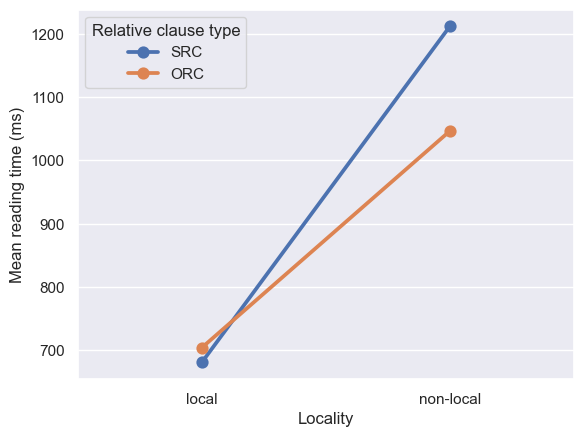

In [3]:
sns.set_theme()

sns.pointplot(expdata.levy_exp1a_verb,
              x = "Locality", 
              y = "Mean reading time (ms)", 
              hue = "Relative clause type"
);

We run the model with the parameters assigned as above and get the following plot:

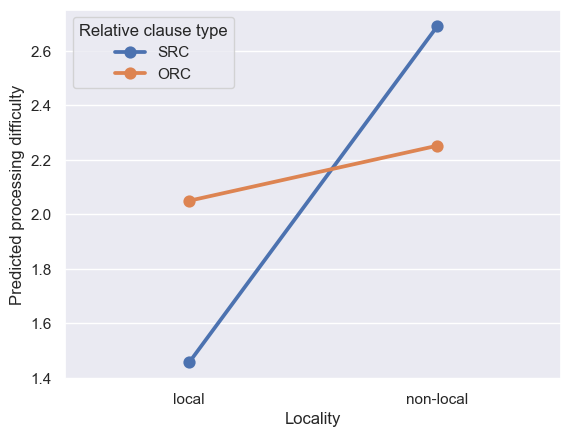

In [4]:
src_local = model_russian.calculate_processing_difficulty("RPNom V".split())
src_non_local = model_russian.calculate_processing_difficulty("RPNom DO V".split())

orc_local = model_russian.calculate_processing_difficulty("RPAcc V".split())
orc_non_local = model_russian.calculate_processing_difficulty("RPAcc Subj V".split())

sim_data_exp1 = pd.DataFrame({
    "Predicted processing difficulty": [src_local, src_non_local, orc_local, orc_non_local],
    "Relative clause type": ["SRC", "SRC", "ORC", "ORC"],
    "Locality": ["local", "non-local", "local", "non-local"]
})

sns.pointplot(sim_data_exp1,
              x = "Locality", 
              y = "Predicted processing difficulty", 
              hue = "Relative clause type"
);

As we can see, although the differences between SRCs and ORCs are much greater in the model, the qualatitive pattern is there:

 - The verb is read slower in the non-local conditions, and
 - local ORCs are read slower than local SRCs, but non-local ORCs are faster than non-local SRCs.

Levy et al. (2013) also looked at the reading time on accusative NPs (in the grammar called 'DO'), and found that these were read slower when placed preverbally than postverbally.

In [5]:
preverbal_acc = model_russian.calculate_processing_difficulty("RPNom DO".split())
postverbal_acc = model_russian.calculate_processing_difficulty("RPNom V DO".split())

diff = preverbal_acc - postverbal_acc
print(diff)

0.4160177432691632


As we can see from this output, the model predicts that preverbal accusative NPs have a higher processing difficulty than postverbal accusative NPs. This is to be expected from an expectation-based standpoint, since, as Levy et al. discuss, local SRC configurations are much more common, meaning a comprehender should expect the word following the nominative relative pronoun to be a verb, not a direct object.

## Experiment 2
The goal of the second experiment was to more directly manipulate the distance between the relative pronoun and the verb. They did this by adding one or two interveners that were either verb arguments (direct object + indirect object) or adjuncts. They results were the following.

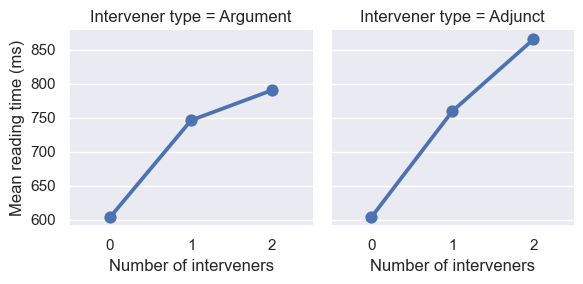

In [6]:
grid = sns.FacetGrid(expdata.levy_exp2a_verb, col = "Intervener type")

grid.map(sns.pointplot, "Number of interveners", "Mean reading time (ms)");

For both types of intervener, the reading time rises monotonically at the verb. We can now see what the model predicts for this.

In [7]:
no_intv = model_russian.calculate_processing_difficulty("RPNom V".split())
one_arg = model_russian.calculate_processing_difficulty("RPNom DO V".split())
two_arg = model_russian.calculate_processing_difficulty("RPNom DO IO V".split())

one_adj = model_russian.calculate_processing_difficulty("RPNom Adj V".split())
two_adj = model_russian.calculate_processing_difficulty("RPNom Adj Adj V".split())

sim_data_exp2 = pd.DataFrame({
    "Predicted processing difficulty": [no_intv, one_arg, two_arg, no_intv, one_adj, two_adj],
    "Number of interveners": [0, 1, 2, 0, 1, 2],
    "Intervener type": ["Argument", "Argument", "Argument", "Adjunct", "Adjunct", "Adjunct"]
})

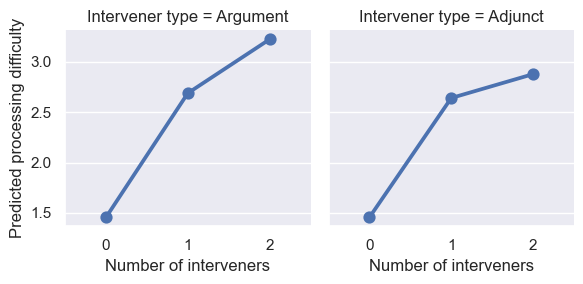

In [8]:
grid = sns.FacetGrid(sim_data_exp2, col = "Intervener type")
grid.map(sns.pointplot, "Number of interveners", "Predicted processing difficulty");

# Strong expectations cancel locality effects: Evidence from Hindi
## Experiment 1
The first experiment was very similar to the first experiment of Levy et al. (2013), where verb locality was crossed with relative clause type. This means that we can use the same grammar her for Hindi as we did for Russian. Hindi is, however, predominantly head_final, meaning . The same deletion rate is used here as for Russian. This assumes that speakers of both languages are equally affected by noise, which might be a proxy for working memory. It has been argued that speakers of head-initial languages have difficulty keeping longer structures in memory (find paper for this). Frank et al. (2015) however found that although German and Dutch speakers exhibit anti-locality in German/Dutch, they show locality effects reading English. This suggests that the difference lies in the distribution of longer and short structures in a certain language, rather than working memory capacity.

In [9]:
pcfg_hindi = PCFG.fromstring(
    grammars.gen_hindi_grammar_exp1(
        p_src = 0.74,
        p_src_local = 0.01,
        p_obj_elision = 0.05,
        p_orc_local = 0.01,
        p_subj_elision = 0.95
    )
)

model_hindi = toylossy.LCModel(pcfg_hindi, del_rate)

The parameters were chosen based on the data from Husain et al. (2014). In a corpus study, the authors found a total of 345 relative clauses. 258 of these were SRCs and 87 ORCs, giving $p(\text{SRC}) = \frac{248}{358}\approx 0.74$. Of the SRCs, only 2 had the non-canonical local word order, from which we get $p(\text{SRC}_\text{Local})=\frac{2}{248}\approx 0.01$. For ORCs, all 87 had the non-local configuration. In order to estimate $p(\text{ORC}_\text{Local})$ I perform Laplace smoothing by adding 1 to the frequency of both non-local and local ORCs, which gives $p(\text{ORC}_\text{Local})=\frac{1}{89}\approx 0.01$.

For the elision probabilities, I turn to the work of Pashad (2001) as cited in Husain et al. (2014). She found that of 209 relative clauses with either type of elision, 199 had subject elisions, while only 10 had object elisions.

The reading times were as follows at the relative clause verb.

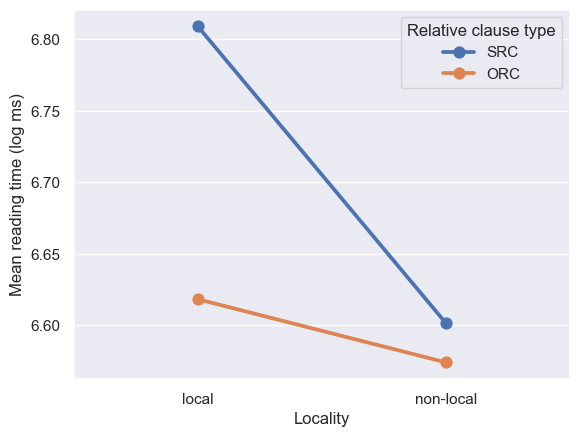

In [10]:
sns.pointplot(expdata.husain_exp1_verb,
              x = "Locality",
              y = "Mean reading time (log ms)",
              hue = "Relative clause type");

Let's look at the predicted data from the model.

In [11]:
src_local = model_hindi.calculate_processing_difficulty("RPErg V".split())
src_non_local  = model_hindi.calculate_processing_difficulty("RPErg DO V".split())

orc_local = model_hindi.calculate_processing_difficulty("RPAcc V".split())
orc_non_local  = model_hindi.calculate_processing_difficulty("RPAcc Subj V".split())

sim_husain_exp1_verb = pd.DataFrame({
    "Predicted processing difficulty": [src_local, src_non_local, orc_local, orc_non_local],
    "Relative clause type": ["SRC", "SRC", "ORC", "ORC"],
    "Locality": ["local", "non-local", "local", "non-local"]
})

True context: RPAcc Subj V
Current distortion: ['RPAcc', 'Subj']
p(r|c) = 0.6400000000000001
 ## Possible reconstructed context: RPAcc Subj
 ## Reconstructing sentence as: RPAcc Subj V
 ## p(r|~c) = 0.6400000000000001
 ## p(w_1,...,w_[i-1],w_i) = 0.012870000000000012

E[p(w|~c)] = 0.012870000000000012

Current distortion: ['RPAcc']
p(r|c) = 0.16000000000000003
 ## Possible reconstructed context: RPAcc
 ## Reconstructing sentence as: RPAcc V
 ## p(r|~c) = 0.8
 ## p(w_1,...,w_[i-1],w_i) = 0.247

 ## Possible reconstructed context: RPAcc Subj
 ## Reconstructing sentence as: RPAcc Subj V
 ## p(r|~c) = 0.16000000000000003
 ## p(w_1,...,w_[i-1],w_i) = 0.012870000000000012

E[p(w|~c)] = 0.20797833333333332

Current distortion: ['Subj']
p(r|c) = 0.16000000000000003
 ## Possible reconstructed context: RPAcc Subj
 ## Reconstructing sentence as: RPAcc Subj V
 ## p(r|~c) = 0.16000000000000003
 ## p(w_1,...,w_[i-1],w_i) = 0.012870000000000012

E[p(w|~c)] = 0.012870000000000012

Current distortion: 

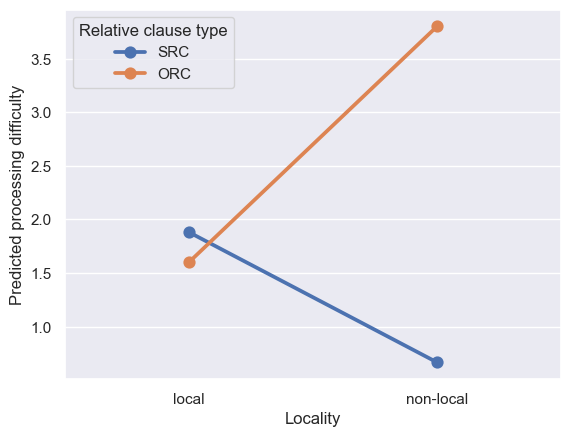

In [12]:
sns.pointplot(sim_husain_exp1_verb,
              x = "Locality",
              y = "Predicted processing difficulty",
              hue = "Relative clause type");

Here, we can see that the results from the model diverge pretty heavily from the empirical results. This is probably due to the fact that the context $\text{RPAcc Subj}$ is quite rare in the language model. This in turn is caused by the high probability of subject elisions. Although the probability $p(\text{V}\mid \text{RPAcc Subj})$ is one, the context is heavily downweighted by its low *a priori* probability. Thus, contexts in which a verb do not follow as often are more heavily weighted and thus contribute more to the average probability of the next word being a verb.

A Hindi reader will however presumably first be surprised by a subject itself; a verb following it should however be very highly expected. This effect could be accounted for by using a memory model which assigns smaller deletion probabilities to more recent words (perhaps an instantion of the recency effect which is well known in the cognitive psychology literature).